In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Load Dataset
df = pd.read_csv("marketing_campaign.csv", sep="\t")

# Display all columns
pd.set_option("display.max_columns", None)

# =========================
# DATA UNDERSTANDING
# =========================

print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

# =========================
# DATA CLEANING
# =========================

# 1. Fill missing Income values using Median
df['Income'] = df['Income'].fillna(df['Income'].median())

# 2. Remove duplicates
df.drop_duplicates(inplace=True)

# 3. Convert Date Column
df['Dt_Customer'] = pd.to_datetime(
    df['Dt_Customer'],
    dayfirst=True
)

# =========================
# FEATURE ENGINEERING
# =========================

# 4. Create Age Feature
df['Age'] = 2026 - df['Year_Birth']

# 5. Create Customer Seniority
df['Customer_Days'] = (
    pd.Timestamp('2026-01-01')
    - df['Dt_Customer']
).dt.days

# 6. Total Children
df['Children'] = (
    df['Kidhome']
    + df['Teenhome']
)

# 7. Total Spending
df['Total_Spending'] = (
    df['MntWines']
    + df['MntFruits']
    + df['MntMeatProducts']
    + df['MntFishProducts']
    + df['MntSweetProducts']
    + df['MntGoldProds']
)

# =========================
# REMOVE UNNECESSARY COLUMNS
# =========================

df.drop(
    columns=[
        'ID',
        'Dt_Customer',
        'Year_Birth'
    ],
    inplace=True
)

# =========================
# ENCODE CATEGORICAL DATA
# =========================

le = LabelEncoder()

df['Education'] = le.fit_transform(df['Education'])
df['Marital_Status'] = le.fit_transform(df['Marital_Status'])

# =========================
# OUTLIER REMOVAL (Income)
# =========================

Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df['Income'] >= lower)
    &
    (df['Income'] <= upper)
]

# =========================
# FINAL CHECK
# =========================

print("\nFinal Shape:", df.shape)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

# =========================
# SAVE CLEANED DATASET
# =========================

df.to_csv(
    "customer_cleaned.csv",
    index=False
)

print("\nCleaned Dataset Saved Successfully!")

Dataset Shape: (2240, 29)

Missing Values:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Duplicate Rows: 0

Final Shape: (2232, 30)

Missing Values After Cleaning:
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome      

In [2]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [3]:
df.isnull().sum()

Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
Age                    0
Customer_Days          0
Children               0
Total_Spending         0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(182)

In [5]:
df = df.drop_duplicates()

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2050 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2050 non-null   int64  
 1   Marital_Status       2050 non-null   int64  
 2   Income               2050 non-null   float64
 3   Kidhome              2050 non-null   int64  
 4   Teenhome             2050 non-null   int64  
 5   Recency              2050 non-null   int64  
 6   MntWines             2050 non-null   int64  
 7   MntFruits            2050 non-null   int64  
 8   MntMeatProducts      2050 non-null   int64  
 9   MntFishProducts      2050 non-null   int64  
 10  MntSweetProducts     2050 non-null   int64  
 11  MntGoldProds         2050 non-null   int64  
 12  NumDealsPurchases    2050 non-null   int64  
 13  NumWebPurchases      2050 non-null   int64  
 14  NumCatalogPurchases  2050 non-null   int64  
 15  NumStorePurchases    2050 non-null   int64 

In [9]:
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Shape:", df.shape)

Missing Values: 0
Duplicate Rows: 0
Shape: (2050, 30)


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(df)

print(X)

[[-0.34905964  0.26045144  0.31350948 ...  1.53560774 -1.27761196
   1.67987251]
 [-0.34905964  0.26045144 -0.25956336 ... -1.18399612  1.39494367
  -0.96212212]
 [-0.34905964  1.19063517  0.96826244 ... -0.199994   -1.27761196
   0.28244013]
 ...
 [-0.34905964 -1.59991601  0.25729061 ... -0.97631728 -1.27761196
   1.05509894]
 [ 0.53764701  1.19063517  0.85320084 ... -0.97137255  0.05866586
   0.39376946]
 [ 1.42435366 -0.66973228  0.05748771 ...  1.33287363  1.39494367
  -0.72118551]]


In [11]:
print(df.head())

   Education  Marital_Status   Income  Kidhome  Teenhome  Recency  MntWines  \
0          2               4  58138.0        0         0       58       635   
1          2               4  46344.0        1         1       38        11   
2          2               5  71613.0        0         0       26       426   
3          2               5  26646.0        1         0       26        11   
4          4               3  58293.0        1         0       94       173   

   MntFruits  MntMeatProducts  MntFishProducts  MntSweetProducts  \
0         88              546              172                88   
1          1                6                2                 1   
2         49              127              111                21   
3          4               20               10                 3   
4         43              118               46                27   

   MntGoldProds  NumDealsPurchases  NumWebPurchases  NumCatalogPurchases  \
0            88                  3      

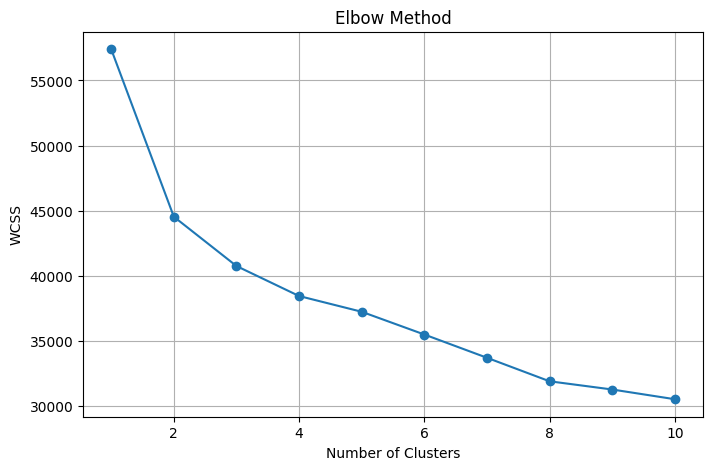

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [13]:
kmeans = KMeans(n_clusters=4, random_state=42)

df['Cluster'] = kmeans.fit_predict(X)

In [14]:
df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,Children,Total_Spending,Cluster
0,2,4,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,69,4867,0,1617,3
1,2,4,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,72,4317,2,27,1
2,2,5,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,61,4516,0,776,3
3,2,5,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,42,4343,1,53,1
4,4,3,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,45,4365,1,422,0


In [15]:
df.groupby('Cluster').mean()

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,Children,Total_Spending
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,2.628942,3.688312,57278.323748,0.241187,0.959184,48.051948,446.365492,20.224490,129.005566,27.968460,21.092764,59.564007,3.853432,6.298701,2.988868,7.612245,5.795918,0.064935,0.139147,0.005566,0.031540,0.011132,0.005566,3.0,11.0,0.109462,61.706865,4608.228200,1.200371,704.220779
1,2.273885,3.710191,34597.200637,0.805732,0.445860,49.198514,41.471338,4.881104,23.244161,6.954352,4.949045,15.384289,2.067941,2.123142,0.549894,3.198514,6.479830,0.074310,0.008493,0.000000,0.001062,0.001062,0.012739,3.0,11.0,0.095541,54.261146,4522.314225,1.251592,96.884289
2,2.518072,3.759036,81393.837349,0.036145,0.120482,48.198795,865.084337,57.554217,482.771084,80.391566,65.301205,78.355422,1.048193,5.506024,6.120482,8.277108,3.036145,0.162651,0.373494,0.873494,0.487952,0.114458,0.006024,3.0,11.0,0.602410,56.385542,4556.216867,0.156627,1629.457831
3,2.307692,3.769231,71913.428040,0.047146,0.220844,49.895782,501.235732,71.717122,418.339950,103.769231,72.081886,76.071960,1.441687,5.265509,5.588089,8.387097,2.995037,0.047146,0.032258,0.000000,0.089330,0.000000,0.009926,3.0,11.0,0.158809,58.516129,4567.064516,0.267990,1243.215881


In [16]:
df.drop(['Z_CostContact', 'Z_Revenue'], axis=1, inplace=True)

In [17]:
cluster_summary = df.groupby('Cluster').mean()
cluster_summary

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Customer_Days,Children,Total_Spending
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,2.628942,3.688312,57278.323748,0.241187,0.959184,48.051948,446.365492,20.224490,129.005566,27.968460,21.092764,59.564007,3.853432,6.298701,2.988868,7.612245,5.795918,0.064935,0.139147,0.005566,0.031540,0.011132,0.005566,0.109462,61.706865,4608.228200,1.200371,704.220779
1,2.273885,3.710191,34597.200637,0.805732,0.445860,49.198514,41.471338,4.881104,23.244161,6.954352,4.949045,15.384289,2.067941,2.123142,0.549894,3.198514,6.479830,0.074310,0.008493,0.000000,0.001062,0.001062,0.012739,0.095541,54.261146,4522.314225,1.251592,96.884289
2,2.518072,3.759036,81393.837349,0.036145,0.120482,48.198795,865.084337,57.554217,482.771084,80.391566,65.301205,78.355422,1.048193,5.506024,6.120482,8.277108,3.036145,0.162651,0.373494,0.873494,0.487952,0.114458,0.006024,0.602410,56.385542,4556.216867,0.156627,1629.457831
3,2.307692,3.769231,71913.428040,0.047146,0.220844,49.895782,501.235732,71.717122,418.339950,103.769231,72.081886,76.071960,1.441687,5.265509,5.588089,8.387097,2.995037,0.047146,0.032258,0.000000,0.089330,0.000000,0.009926,0.158809,58.516129,4567.064516,0.267990,1243.215881


In [18]:
df["Total_Spending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

In [19]:
df.drop([
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
], axis=1, inplace=True)

In [20]:
df['AcceptedCampaigns'] = (
    df['AcceptedCmp1'] +
    df['AcceptedCmp2'] +
    df['AcceptedCmp3'] +
    df['AcceptedCmp4'] +
    df['AcceptedCmp5']
)

In [21]:
df.drop([
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5'
], axis=1, inplace=True)

In [22]:
df['TotalPurchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)

In [23]:
df.drop([
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases'
], axis=1, inplace=True)

In [24]:
Children = Kidhome + Teenhome

NameError: name 'Kidhome' is not defined

In [ ]:
cluster_summary = df.groupby('Cluster').mean()
cluster_summary

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Days,Children,Total_Spending,AcceptedCampaigns,TotalPurchases
Cluster,,,,,,,,,,,,,,,,
0,2.628942,3.688312,57278.323748,0.241187,0.959184,48.051948,3.853432,5.795918,0.005566,0.109462,61.706865,4608.228200,1.200371,704.220779,0.252319,16.899814
1,2.273885,3.710191,34597.200637,0.805732,0.445860,49.198514,2.067941,6.479830,0.012739,0.095541,54.261146,4522.314225,1.251592,96.884289,0.084926,5.871550
2,2.518072,3.759036,81393.837349,0.036145,0.120482,48.198795,1.048193,3.036145,0.006024,0.602410,56.385542,4556.216867,0.156627,1629.457831,2.012048,19.903614
3,2.307692,3.769231,71913.428040,0.047146,0.220844,49.895782,1.441687,2.995037,0.009926,0.158809,58.516129,4567.064516,0.267990,1243.215881,0.168734,19.240695


In [ ]:
df.drop(['Kidhome', 'Teenhome'], axis=1, inplace=True)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(df)

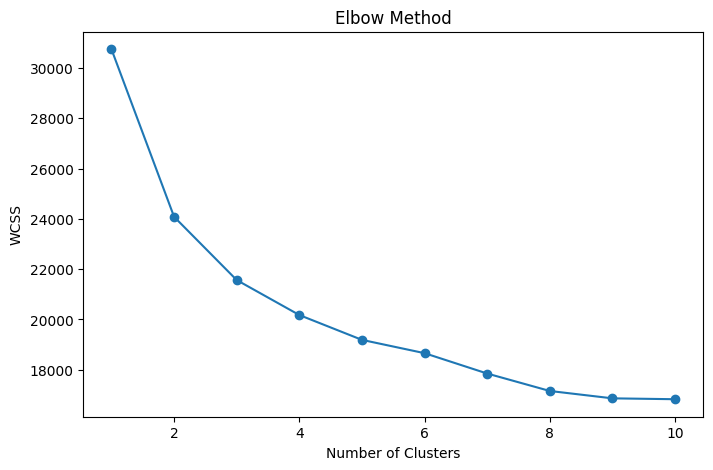

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)

df['Cluster'] = kmeans.fit_predict(X)

In [ ]:
df['Cluster'].value_counts()

Cluster
2    921
0    563
1    413
3    153
Name: count, dtype: int64

In [ ]:
cluster_summary = df.groupby('Cluster').mean()

cluster_summary

,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Days,Children,Total_Spending,AcceptedCampaigns,TotalPurchases
Cluster,,,,,,,,,,,,,,
0,2.662522,3.698046,56160.823268,48.584369,4.103020,6.005329,0.007105,0.120782,61.218472,4621.603908,1.250444,689.461812,0.250444,16.619893
1,2.336562,3.784504,73137.090799,50.832930,1.343826,2.857143,0.009685,0.121065,58.789346,4558.268765,0.256659,1265.128329,0.191283,19.244552
2,2.234528,3.706840,34629.429967,48.971770,1.896851,6.376764,0.011944,0.085776,54.344191,4513.554832,1.221498,94.622150,0.079262,5.825190
3,2.516340,3.705882,79988.241830,45.124183,1.098039,3.300654,0.006536,0.758170,55.679739,4569.947712,0.163399,1598.261438,2.124183,19.790850


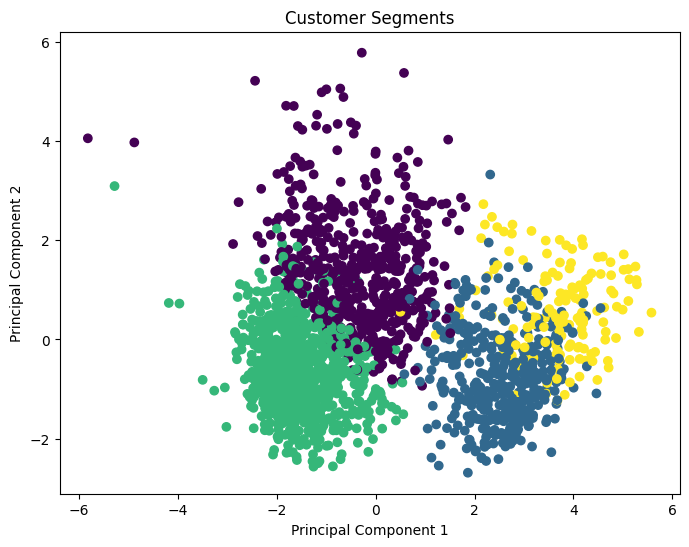

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments")
plt.show()

In [ ]:
df.to_csv("customer_segments.csv", index=False)

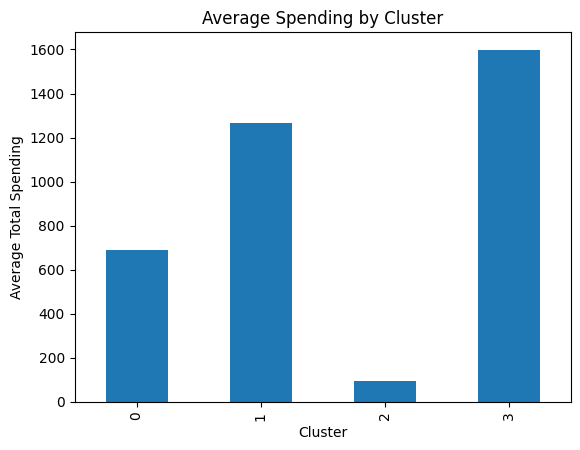

In [ ]:
import matplotlib.pyplot as plt

df.groupby('Cluster')['Total_Spending'].mean().plot(kind='bar')

plt.title("Average Spending by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Total Spending")
plt.show()

In [ ]:
df.to_csv("customer_segments.csv", index=False)

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, df['Cluster'])

print("Silhouette Score:", score)

Silhouette Score: 0.17906297990215486


In [ ]:
df.to_csv("customer_segments.csv", index=False)

In [ ]:
df.shape

(2050, 15)

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

kmeans.fit(X)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [ ]:
df['Cluster'] = kmeans.predict(X)

In [ ]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")

['kmeans_model.pkl']

In [ ]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
print(df.columns)

Index(['Education', 'Marital_Status', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age', 'Customer_Days',
       'Children', 'Total_Spending', 'Cluster', 'AcceptedCampaigns',
       'TotalPurchases'],
      dtype='object')


In [ ]:
X = df.drop('Cluster', axis=1)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

kmeans.fit(X_scaled)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [ ]:
df['Cluster'] = kmeans.predict(X_scaled)

In [ ]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
feature_columns = X.columns.tolist()

joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']

In [ ]:
cluster_names = {
    0: "Regular Customer",
    1: "High-Value Customer",
    2: "Low-Value Customer",
    3: "Premium Loyal Customer"
}

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

kmeans.fit(X)

df["Cluster"] = kmeans.predict(X)

In [ ]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")

['kmeans_model.pkl']

In [ ]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
feature_columns = [
    'Education',
    'Marital_Status',
    'Income',
    'Recency',
    'NumDealsPurchases',
    'NumWebVisitsMonth',
    'Complain',
    'Response',
    'Age',
    'Customer_Days',
    'Children',
    'Total_Spending',
    'AcceptedCampaigns',
    'TotalPurchases'
]

joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=4, random_state=42)

kmeans_labels = kmeans.fit_predict(X)

kmeans_score = silhouette_score(X, kmeans_labels)

print("K-Means Silhouette Score:", kmeans_score)

K-Means Silhouette Score: 0.526793944706895


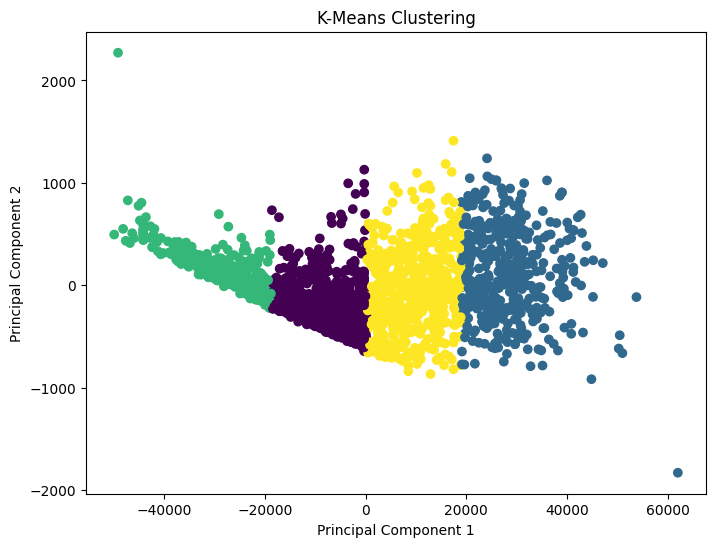

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels,
    cmap='viridis'
)

plt.title("K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=4)

hc_labels = hc.fit_predict(X)

hc_score = silhouette_score(X, hc_labels)

print("Hierarchical Clustering Silhouette Score:", hc_score)

Hierarchical Clustering Silhouette Score: 0.5137789174547297


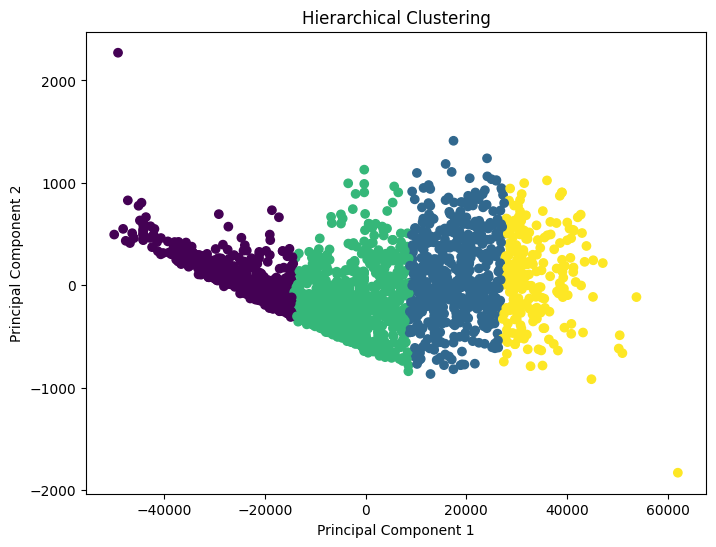

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=hc_labels,
    cmap='viridis'
)

plt.title("Hierarchical Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X)

print(set(dbscan_labels))

{np.int64(-1)}


In [ ]:
dbscan = DBSCAN(eps=3.0, min_samples=5)

In [ ]:
dbscan = DBSCAN(eps=4.0, min_samples=5)

In [ ]:
import numpy as np

print("Unique Labels:", np.unique(dbscan_labels))
print("Number of Clusters:", len(set(dbscan_labels)))

Unique Labels: [-1]
Number of Clusters: 1


In [ ]:
import pandas as pd

print(pd.Series(dbscan_labels).value_counts())

-1    2050
Name: count, dtype: int64


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
# 3D PCA
pca = PCA(n_components=3, random_state=42)

X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.2629067  0.11697986 0.10068822]


In [ ]:
labels = {
    "K-Means": kmeans_labels,
    "Agglomerative": agg_labels,
    "DBSCAN": dbscan_labels,
    "Gaussian Mixture": gmm_labels
}

fig = plt.figure(figsize=(20,15))

for i, (name, cluster_labels) in enumerate(labels.items(), 1):

    ax = fig.add_subplot(2,2,i, projection='3d')

    scatter = ax.scatter(
        X_pca[:,0],
        X_pca[:,1],
        X_pca[:,2],
        c=cluster_labels,
        cmap='viridis',
        s=18
    )

    ax.set_title(f"{name} - 3D PCA")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")

    plt.colorbar(scatter, ax=ax)

plt.tight_layout()
plt.show()

NameError: name 'agg_labels' is not defined

In [ ]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

agg_labels = agg.fit_predict(X_scaled)

In [ ]:
print(kmeans_labels.shape)
print(agg_labels.shape)
print(dbscan_labels.shape)
print(gmm_labels.shape)

(2050,)
(2050,)
(2050,)


NameError: name 'gmm_labels' is not defined

In [ ]:
from sklearn.mixture import GaussianMixture

# Train Gaussian Mixture Model
gmm = GaussianMixture(
    n_components=4,
    random_state=42
)

gmm.fit(X_scaled)

# Predict cluster labels
gmm_labels = gmm.predict(X_scaled)

print("GMM Labels Shape:", gmm_labels.shape)

GMM Labels Shape: (2050,)


In [ ]:
print(kmeans_labels.shape)
print(agg_labels.shape)
print(dbscan_labels.shape)
print(gmm_labels.shape)

(2050,)
(2050,)
(2050,)
(2050,)


In [25]:
print(kmeans_labels.shape)
print(agg_labels.shape)
print(dbscan_labels.shape)
print(gmm_labels.shape)

NameError: name 'kmeans_labels' is not defined

In [27]:
from sklearn.preprocessing import StandardScaler

# Select only numerical columns
X = df.select_dtypes(include=['int64', 'float64'])

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(2050, 16)


In [29]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)

from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [30]:
# Remove datetime columns if any
X = df.select_dtypes(include=['number'])

print(X.shape)
X.head()

(2050, 17)


,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Days,Children,Total_Spending,Cluster,AcceptedCampaigns,TotalPurchases
0,2,4,58138.0,0,0,58,3,7,0,1,69,4867,0,1617,3,0,22
1,2,4,46344.0,1,1,38,2,5,0,0,72,4317,2,27,1,0,4
2,2,5,71613.0,0,0,26,1,4,0,0,61,4516,0,776,3,0,20
3,2,5,26646.0,1,0,26,2,6,0,0,42,4343,1,53,1,0,6
4,4,3,58293.0,1,0,94,5,5,0,0,45,4365,1,422,0,0,14


In [31]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(2050, 17)


In [32]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

print("K-Means completed!")

K-Means completed!


In [33]:
agg = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

agg_labels = agg.fit_predict(X_scaled)

print("Agglomerative completed!")

Agglomerative completed!


In [34]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=8
)

dbscan_labels = dbscan.fit_predict(X_scaled)

print("DBSCAN completed!")

DBSCAN completed!


In [35]:
gmm = GaussianMixture(
    n_components=4,
    random_state=42
)

gmm_labels = gmm.fit_predict(X_scaled)

print("Gaussian Mixture completed!")

Gaussian Mixture completed!


In [36]:
models = {
    "K-Means": kmeans_labels,
    "Agglomerative": agg_labels,
    "DBSCAN": dbscan_labels,
    "Gaussian Mixture": gmm_labels
}

results = []

for name, labels in models.items():

    # Ignore noise points for DBSCAN
    if name == "DBSCAN":

        mask = labels != -1

        if len(np.unique(labels[mask])) < 2:
            results.append([name, "N/A", "N/A", "N/A"])
            continue

        X_eval = X_scaled[mask]
        labels_eval = labels[mask]

    else:

        X_eval = X_scaled
        labels_eval = labels

    silhouette = silhouette_score(X_eval, labels_eval)
    dbi = davies_bouldin_score(X_eval, labels_eval)
    ch = calinski_harabasz_score(X_eval, labels_eval)

    results.append([
        name,
        silhouette,
        dbi,
        ch
    ])

In [37]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Score"
    ]
)

results_df

,Model,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,K-Means,0.175207,1.959438,374.954393
1,Agglomerative,0.156256,1.701793,346.132216
2,DBSCAN,0.284829,1.313917,115.045463
3,Gaussian Mixture,0.151564,2.270882,316.317779


In [38]:
cluster_df = df.copy()

cluster_df["KMeans"] = kmeans_labels
cluster_df["Agglomerative"] = agg_labels
cluster_df["DBSCAN"] = dbscan_labels
cluster_df["GMM"] = gmm_labels

cluster_df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Days,Children,Total_Spending,Cluster,AcceptedCampaigns,TotalPurchases,KMeans,Agglomerative,DBSCAN,GMM
0,2,4,58138.0,0,0,58,3,7,0,1,69,4867,0,1617,3,0,22,0,1,-1,3
1,2,4,46344.0,1,1,38,2,5,0,0,72,4317,2,27,1,0,4,3,0,0,1
2,2,5,71613.0,0,0,26,1,4,0,0,61,4516,0,776,3,0,20,0,1,-1,3
3,2,5,26646.0,1,0,26,2,6,0,0,42,4343,1,53,1,0,6,1,2,1,1
4,4,3,58293.0,1,0,94,5,5,0,0,45,4365,1,422,0,0,14,1,2,-1,0


In [39]:
cluster_df.to_csv("customer_segments_4_models.csv", index=False)

print("Saved Successfully!")

Saved Successfully!


In [40]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [41]:
pca = PCA(n_components=3, random_state=42)

X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.26915156 0.12977982 0.09331543]


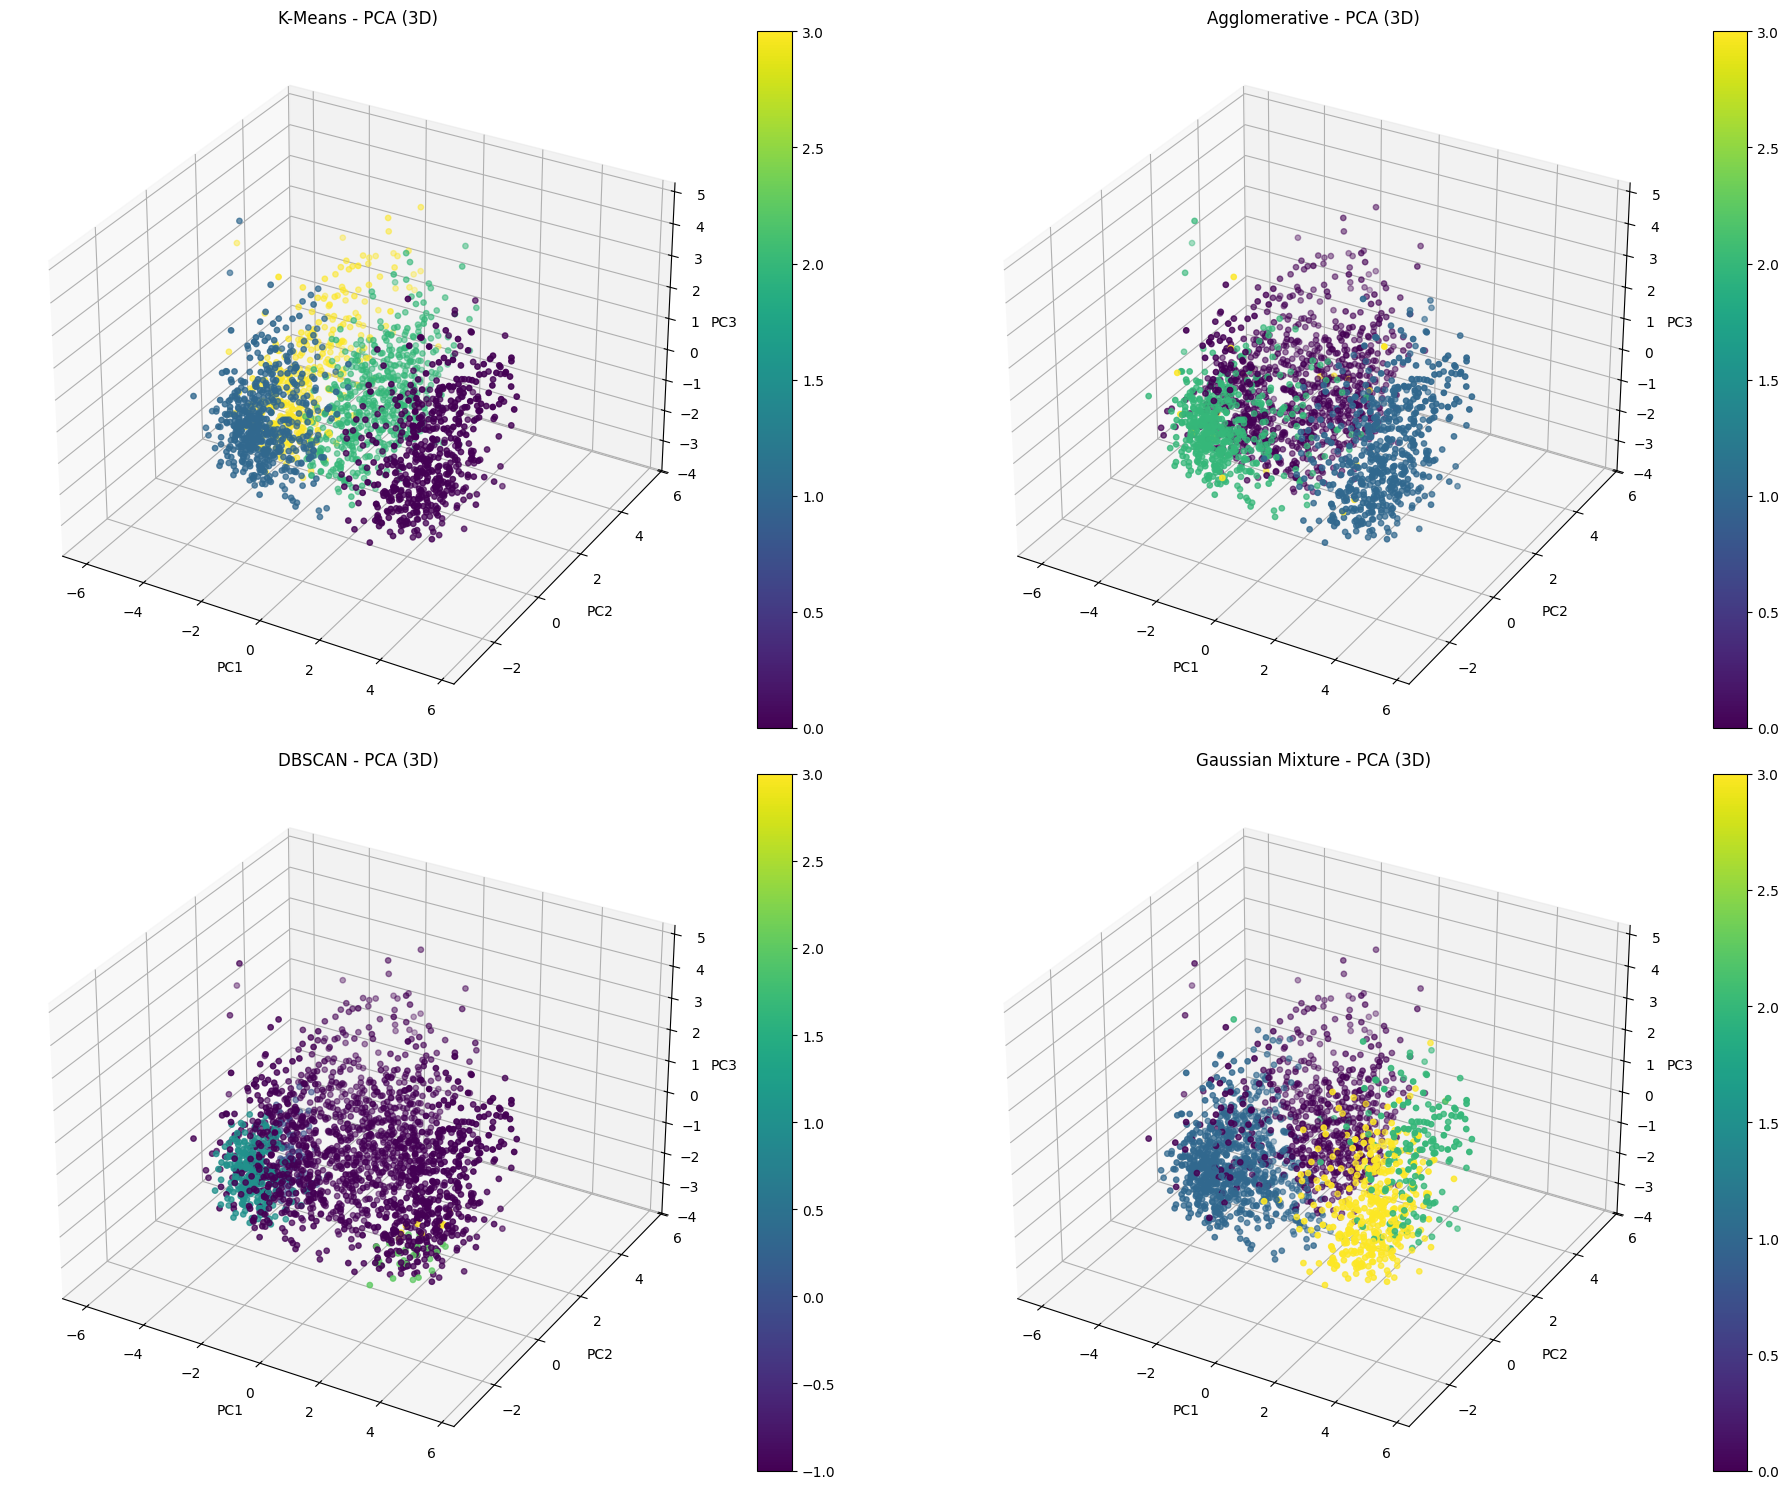

In [42]:
labels = {
    "K-Means": kmeans_labels,
    "Agglomerative": agg_labels,
    "DBSCAN": dbscan_labels,
    "Gaussian Mixture": gmm_labels
}

fig = plt.figure(figsize=(20,15))

for i, (name, cluster_labels) in enumerate(labels.items(), 1):

    ax = fig.add_subplot(2,2,i, projection='3d')

    scatter = ax.scatter(
        X_pca[:,0],
        X_pca[:,1],
        X_pca[:,2],
        c=cluster_labels,
        cmap='viridis',
        s=15
    )

    ax.set_title(f"{name} - PCA (3D)")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")

    plt.colorbar(scatter, ax=ax)

plt.tight_layout()
plt.show()

In [43]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=3,
    random_state=42,
    perplexity=30,
    learning_rate='auto',
    init='pca'
)

X_tsne = tsne.fit_transform(X_scaled)

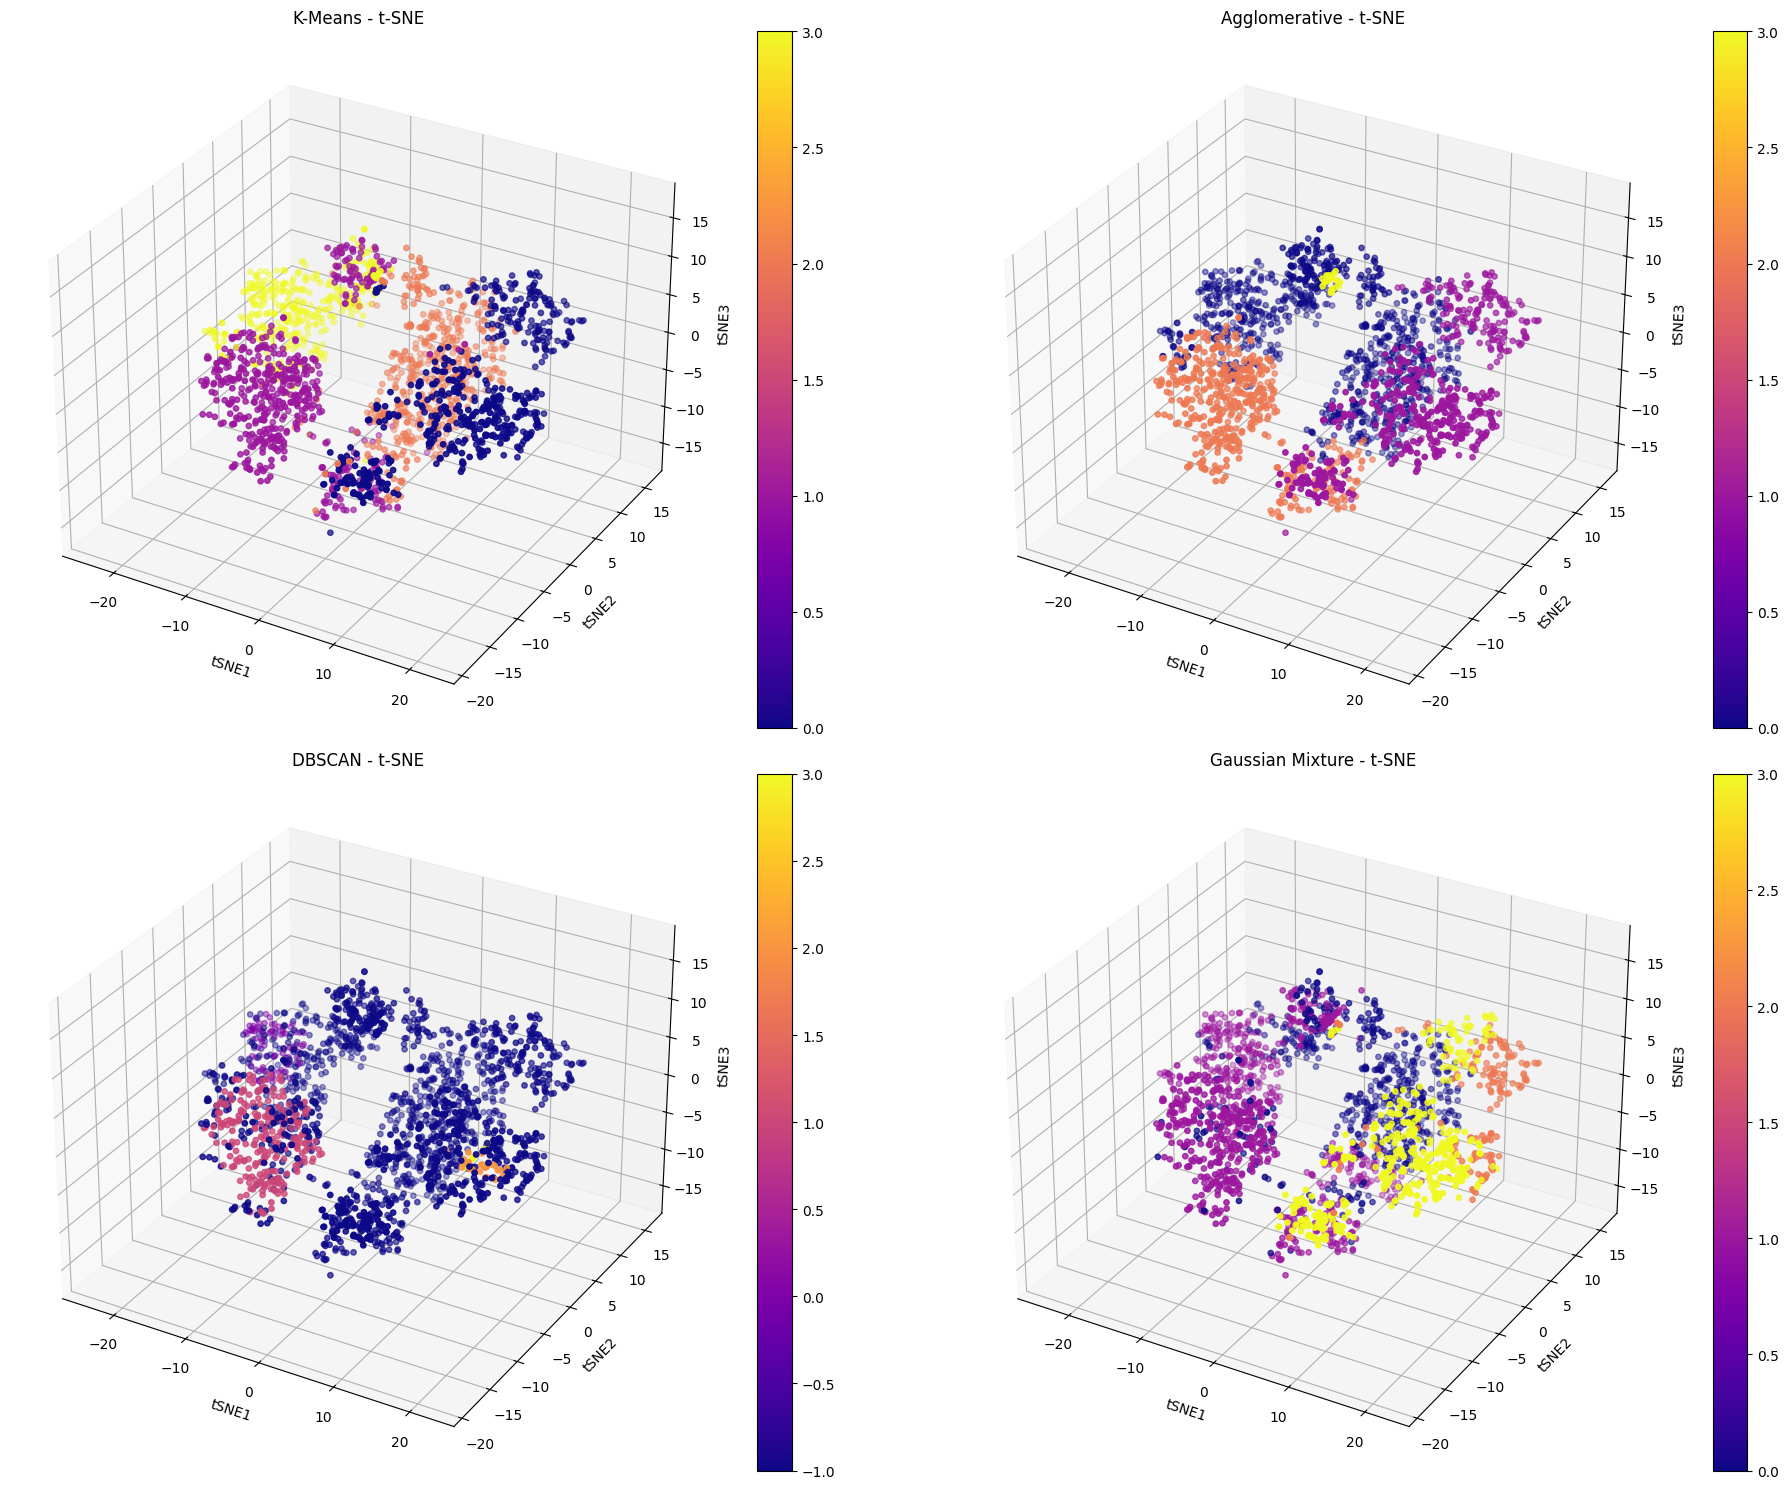

In [44]:
labels = {
    "K-Means": kmeans_labels,
    "Agglomerative": agg_labels,
    "DBSCAN": dbscan_labels,
    "Gaussian Mixture": gmm_labels
}

fig = plt.figure(figsize=(20,15))

for i, (name, cluster_labels) in enumerate(labels.items(),1):

    ax = fig.add_subplot(2,2,i, projection='3d')

    scatter=ax.scatter(
        X_tsne[:,0],
        X_tsne[:,1],
        X_tsne[:,2],
        c=cluster_labels,
        cmap='plasma',
        s=15
    )

    ax.set_title(name+" - t-SNE")
    ax.set_xlabel("tSNE1")
    ax.set_ylabel("tSNE2")
    ax.set_zlabel("tSNE3")

    plt.colorbar(scatter, ax=ax)

plt.tight_layout()
plt.show()

In [45]:
import umap.umap_ as umap

In [46]:
reducer = umap.UMAP(
    n_components=3,
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

c:\Users\user\OneDrive\Desktop\internship\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


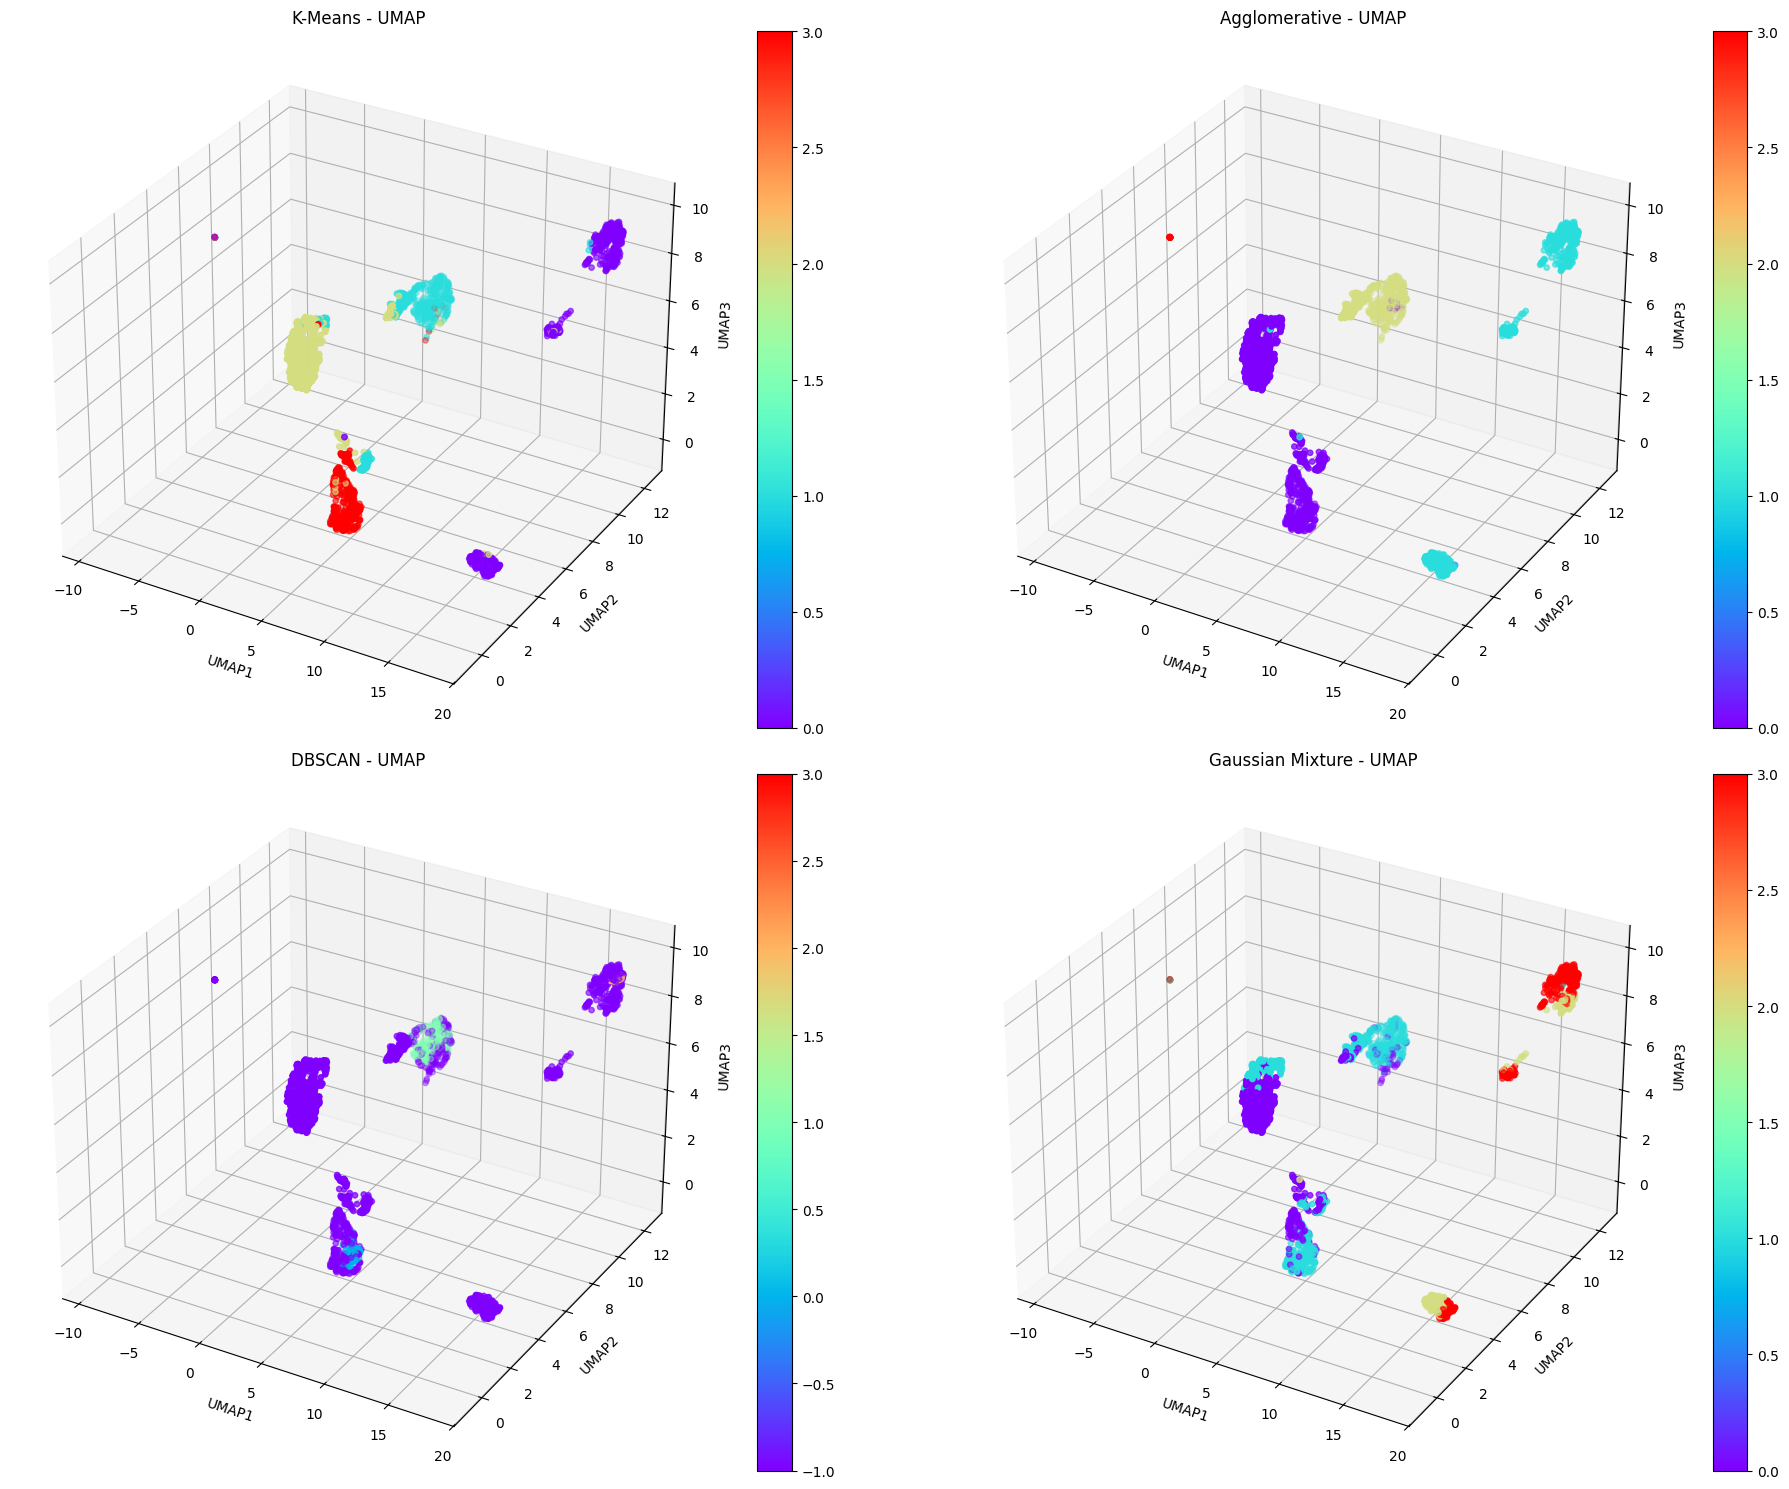

In [47]:
labels = {
    "K-Means": kmeans_labels,
    "Agglomerative": agg_labels,
    "DBSCAN": dbscan_labels,
    "Gaussian Mixture": gmm_labels
}

fig = plt.figure(figsize=(20,15))

for i, (name, cluster_labels) in enumerate(labels.items(),1):

    ax = fig.add_subplot(2,2,i, projection='3d')

    scatter=ax.scatter(
        X_umap[:,0],
        X_umap[:,1],
        X_umap[:,2],
        c=cluster_labels,
        cmap='rainbow',
        s=15
    )

    ax.set_title(name+" - UMAP")
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_zlabel("UMAP3")

    plt.colorbar(scatter, ax=ax)

plt.tight_layout()
plt.show()

In [48]:
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

results = []

models = {
    "K-Means": kmeans_labels,
    "Agglomerative": agg_labels,
    "DBSCAN": dbscan_labels,
    "Gaussian Mixture": gmm_labels
}

for model_name, labels in models.items():

    # DBSCAN may assign -1 to noise points
    if model_name == "DBSCAN":
        mask = labels != -1

        # Need at least 2 clusters after removing noise
        if len(np.unique(labels[mask])) < 2:
            score = np.nan
        else:
            score = silhouette_score(X_scaled[mask], labels[mask])

    else:
        score = silhouette_score(X_scaled, labels)

    results.append([model_name, score])

silhouette_df = pd.DataFrame(
    results,
    columns=["Model", "Silhouette Score"]
)

print(silhouette_df)

              Model  Silhouette Score
0           K-Means          0.175207
1     Agglomerative          0.156256
2            DBSCAN          0.284829
3  Gaussian Mixture          0.151564


In [49]:
silhouette_df = silhouette_df.sort_values(
    by="Silhouette Score",
    ascending=False
)

print(silhouette_df)

              Model  Silhouette Score
2            DBSCAN          0.284829
0           K-Means          0.175207
1     Agglomerative          0.156256
3  Gaussian Mixture          0.151564


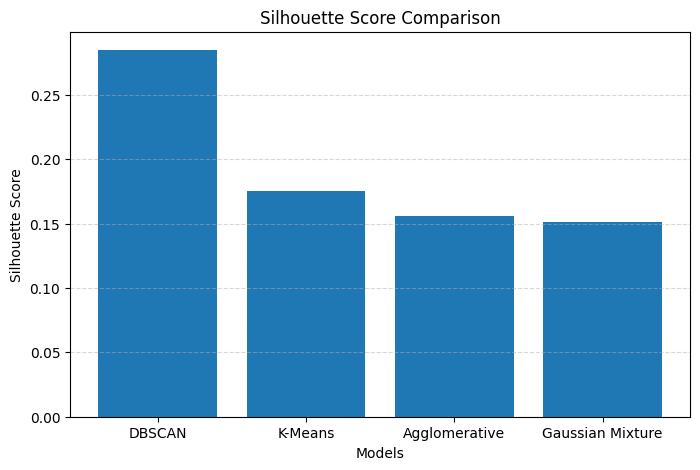

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    silhouette_df["Model"],
    silhouette_df["Silhouette Score"]
)

plt.title("Silhouette Score Comparison")
plt.xlabel("Models")
plt.ylabel("Silhouette Score")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [51]:
print("K-Means:", len(set(kmeans_labels)))
print("Agglomerative:", len(set(agg_labels)))
print("DBSCAN:", len(set(dbscan_labels)))
print("Gaussian Mixture:", len(set(gmm_labels)))

print("\nDBSCAN label counts:")
print(pd.Series(dbscan_labels).value_counts())

K-Means: 4
Agglomerative: 4
DBSCAN: 5
Gaussian Mixture: 4

DBSCAN label counts:
-1    1690
 1     246
 0      80
 2      26
 3       8
Name: count, dtype: int64


In [52]:
dbscan = DBSCAN(
    eps=2.0,      # try 1.8, 2.0, 2.2, 2.5
    min_samples=5 # try 4, 5, 6
)

In [53]:
cluster_summary = df.copy()

cluster_summary["Cluster"] = kmeans_labels

summary = cluster_summary.groupby("Cluster").mean(numeric_only=True)

print(summary)

         Education  Marital_Status        Income   Kidhome  Teenhome  \
Cluster                                                                
0         2.376786        3.764286  75098.338393  0.042857  0.178571   
1         2.066908        3.699819  29929.839964  0.817360  0.023508   
2         2.678309        3.722426  55582.053309  0.025735  0.966912   
3         2.483461        3.681934  43544.936387  1.078880  1.035623   

           Recency  NumDealsPurchases  NumWebVisitsMonth  Complain  Response  \
Cluster                                                                        
0        49.242857           1.264286           2.944643  0.008929  0.289286   
1        48.379747           1.978300           6.918626  0.010850  0.119349   
2        48.568015           2.794118           5.409926  0.005515  0.079044   
3        49.880407           3.709924           6.414758  0.015267  0.106870   

               Age  Customer_Days  Children  Total_Spending  \
Cluster                

In [55]:
cluster_summary = df.groupby("Cluster").agg({
    "Income": "mean",
    "Age": "mean",
    "Total_Spending": "mean",
    "TotalPurchases": "mean",
    "AcceptedCampaigns": "mean",
    "NumWebVisitsMonth": "mean",
    "Recency": "mean"
}).round(2)

print(cluster_summary)

           Income    Age  Total_Spending  TotalPurchases  AcceptedCampaigns  \
Cluster                                                                       
0        75098.34  57.95         1358.07           19.43               0.71   
1        29929.84  48.25          113.53            6.16               0.09   
2        55582.05  63.08          616.69           15.25               0.23   
3        43544.94  60.72          212.63            7.93               0.11   

         NumWebVisitsMonth  Recency  
Cluster                              
0                     2.94    49.24  
1                     6.92    48.38  
2                     5.41    48.57  
3                     6.41    49.88  


In [56]:
print(df["Cluster"].value_counts())

Cluster
0    560
1    553
2    544
3    393
Name: count, dtype: int64


In [57]:
cluster_summary = df.groupby("Cluster").agg({
    "Income": "mean",
    "Age": "mean",
    "Total_Spending": "mean",
    "TotalPurchases": "mean",
    "AcceptedCampaigns": "mean",
    "NumWebVisitsMonth": "mean",
    "Recency": "mean"
}).round(2)

print(cluster_summary)

           Income    Age  Total_Spending  TotalPurchases  AcceptedCampaigns  \
Cluster                                                                       
0        75098.34  57.95         1358.07           19.43               0.71   
1        29929.84  48.25          113.53            6.16               0.09   
2        55582.05  63.08          616.69           15.25               0.23   
3        43544.94  60.72          212.63            7.93               0.11   

         NumWebVisitsMonth  Recency  
Cluster                              
0                     2.94    49.24  
1                     6.92    48.38  
2                     5.41    48.57  
3                     6.41    49.88  
